In [2]:
library(tidyverse)
library(ggplot2)
library(lubridate)
library(zoo)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

载入程序包：'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




In [3]:
crime_all <- read_csv("Original_Crime_data/crime_in_vancouver.csv")|>
    mutate(date = as.Date(paste(year, month, day, sep = "-")))|>
    filter(!is.na(time_category))|>
    select(type, date, year, month, geo_local_area, time_category)|>
    glimpse()

Rows: 811320 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): type, hundred_block, geo_local_area, time_category
dbl (4): year, month, day, hour

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 811,320
Columns: 6
$ type           <chr> "Break and Enter Commercial", "Break and Enter Commerci…
$ date           <date> 2012-12-14, 2019-03-07, 2019-08-27, 2021-04-26, 2014-0…
$ year           <dbl> 2012, 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2005, 2…
$ month          <dbl> 12, 3, 8, 4, 8, 7, 11, 1, 11, 5, 7, 6, 4, 9, 1, 11, 2, …
$ geo_local_area <chr> "South Cambie", "Fairview", "West End", "West End", "We…
$ time_category  <chr> "day", "night", "night", "night", "night", "night", "ni…


In [4]:
type_summary <- crime_all|>
    filter(!is.na(geo_local_area))|>
    group_by(geo_local_area, time_category, type)|>
    summarise(count = n())

type_summary

`summarise()` has grouped output by 'geo_local_area', 'time_category'. You can
override using the `.groups` argument.


geo_local_area,time_category,type,count
<chr>,<chr>,<chr>,<int>
Arbutus Ridge,day,Break and Enter Commercial,92
Arbutus Ridge,day,Break and Enter Residential/Other,912
Arbutus Ridge,day,Mischief,378
Arbutus Ridge,day,Other Theft,1159
Arbutus Ridge,day,Theft from Vehicle,637
Arbutus Ridge,day,Theft of Bicycle,136
Arbutus Ridge,day,Theft of Vehicle,165
Arbutus Ridge,night,Break and Enter Commercial,391
Arbutus Ridge,night,Break and Enter Residential/Other,1165


In [5]:
lum_data <- read_csv("NTL_data/ntl_vancouver_monthly_total_ntl.csv")|>
    glimpse()

Rows: 78 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): total_ntl, total_pixels, weighted_ntl_mean, prev_weighted_ntl_mean
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 78
Columns: 5
$ date                   <date> 2012-01-01, 2012-03-01, 2012-05-01, 2012-07-01…
$ total_ntl              <dbl> NA, 9.5066512, -3.7940151, 1.8771791, 9.7744734…
$ total_pixels           <dbl> 3650, 3853, 3868, 3868, 3868, 3434, 3862, 3861,…
$ weighted_ntl_mean      <dbl> 4.522459, 4.952393, 4.764499, 4.853937, 5.32838…
$ prev_weighted_ntl_mean <dbl> NA, 4.522459, 4.952393, 4.764499, 4.853937, 5.3…


In [6]:
crime_summary_neighbourhood <- crime_all|>
    filter(year != 2025)|>
    filter(!geo_local_area %in% c(NA, "Musqueam", "Stanley Park"))|>
    group_by(geo_local_area)|>
    summarise(crime_count = n())|>
    arrange(desc(crime_count))

print(crime_summary_neighbourhood)

# A tibble: 22 × 2
   geo_local_area           crime_count
   <chr>                          <int>
 1 Downtown                      221662
 2 West End                       73711
 3 Fairview                       51612
 4 Mount Pleasant                 50280
 5 Strathcona                     46084
 6 Grandview-Woodland             46030
 7 Renfrew-Collingwood            42222
 8 Kitsilano                      41390
 9 Kensington-Cedar Cottage       33436
10 Hastings-Sunrise               28159
# ℹ 12 more rows


In [7]:
daily_ntl <- read_csv("NTL_data/ntl_2012_2024_daily.csv")|>
    filter(!is.na(ntl_mean))|>
    glimpse()

Rows: 4749 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,830
Columns: 5
$ ntl_mean           <dbl> 4.346262, 4.281751, 4.284582, 4.283045, 4.015064, 4…
$ n_pixels           <dbl> 907, 907, 907, 907, 907, 907, 907, 907, 907, 907, 9…
$ n_non_na_pixels    <dbl> 887, 890, 891, 889, 905, 905, 907, 903, 903, 904, 9…
$ prop_non_na_pixels <dbl> 0.9779493, 0.9812569, 0.9823594, 0.9801544, 0.99779…
$ date               <date> 2012-01-19, 2012-01-20, 2012-01-21, 2012-01-22, 20…


In [8]:
daily_ntl <- daily_ntl|>
    arrange(desc(ntl_mean))

head(daily_ntl, 10)

ntl_mean,n_pixels,n_non_na_pixels,prop_non_na_pixels,date
<dbl>,<dbl>,<dbl>,<dbl>,<date>
16.649954,907,905,0.9977949,2021-12-27
15.769461,907,904,0.9966924,2022-12-22
12.100985,907,903,0.9955899,2021-12-28
11.797810,907,903,0.9955899,2021-12-29
9.943578,907,904,0.9966924,2017-01-04
9.845053,907,900,0.9922822,2018-02-22
9.748865,907,904,0.9966924,2017-01-03
9.692175,907,905,0.9977949,2019-02-14
9.578393,907,904,0.9966924,2019-02-11


In [9]:
ntl_12_24_monthly <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01"), format = "%Y-%m-%d"))|>
    glimpse()

Rows: 3432 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 7
$ name               <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ geo_point_2d       <chr> "{ \"lon\": -123.11656700827415, \"lat\": 49.280747…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
Warning message:
"Removed 242 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 242 rows containing missing values or values outside the scale range
(`geom_point()`)."


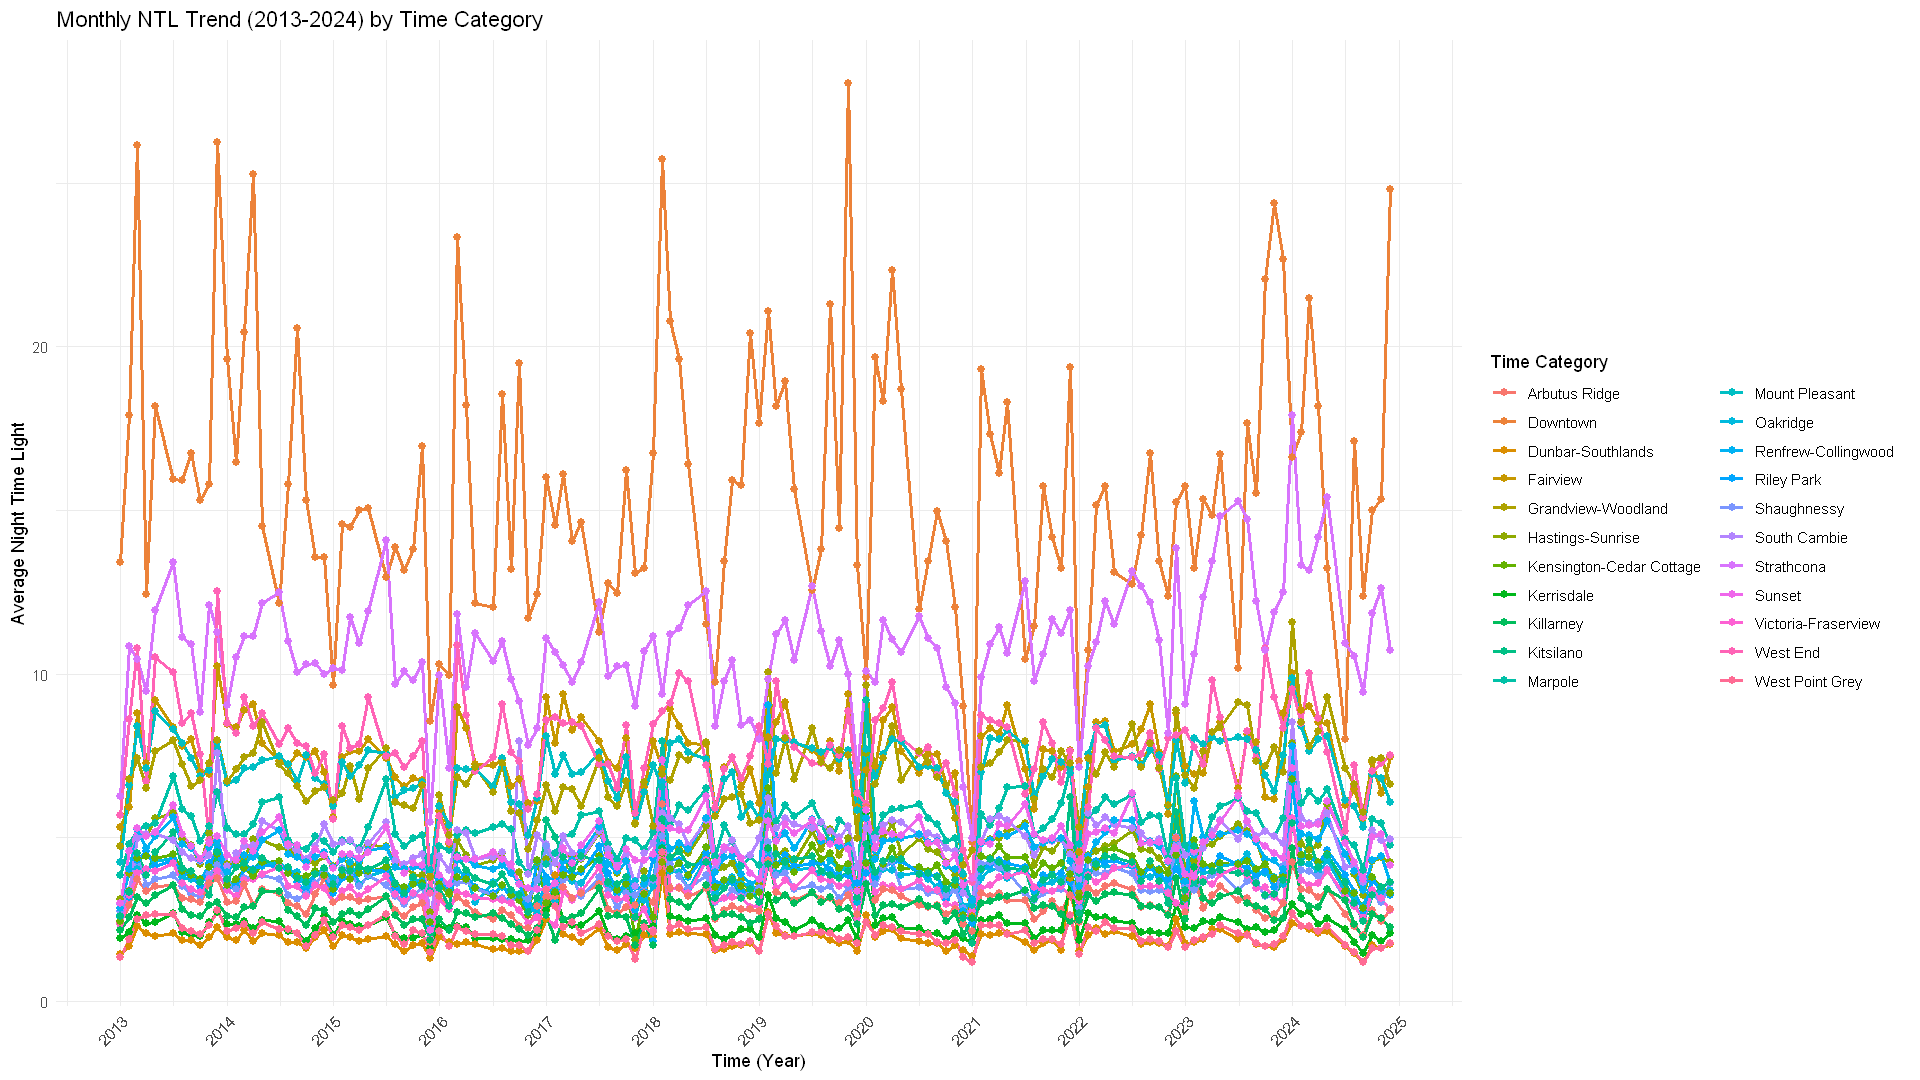

In [10]:
options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(ntl_12_24_monthly, aes(x = date, y = ntl_mean, color = name, group = name)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [11]:
crime_trend_neighborhood <- crime_all|>
    filter(!is.na(geo_local_area))|>
    group_by(time_category, year, month, geo_local_area)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    filter(time_category == "night")|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()


Rows: 5,874
Columns: 6
$ time_category  <chr> "night", "night", "night", "night", "night", "night", "…
$ year           <dbl> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2…
$ month          <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ geo_local_area <chr> "Arbutus Ridge", "Downtown", "Dunbar-Southlands", "Fair…
$ crime_count    <int> 52, 740, 67, 201, 229, 126, 143, 38, 77, 235, 87, 123, …
$ date           <date> 2003-01-01, 2003-01-01, 2003-01-01, 2003-01-01, 2003-0…


Warning message:
"Removed 66 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 66 rows containing missing values or values outside the scale range
(`geom_point()`)."


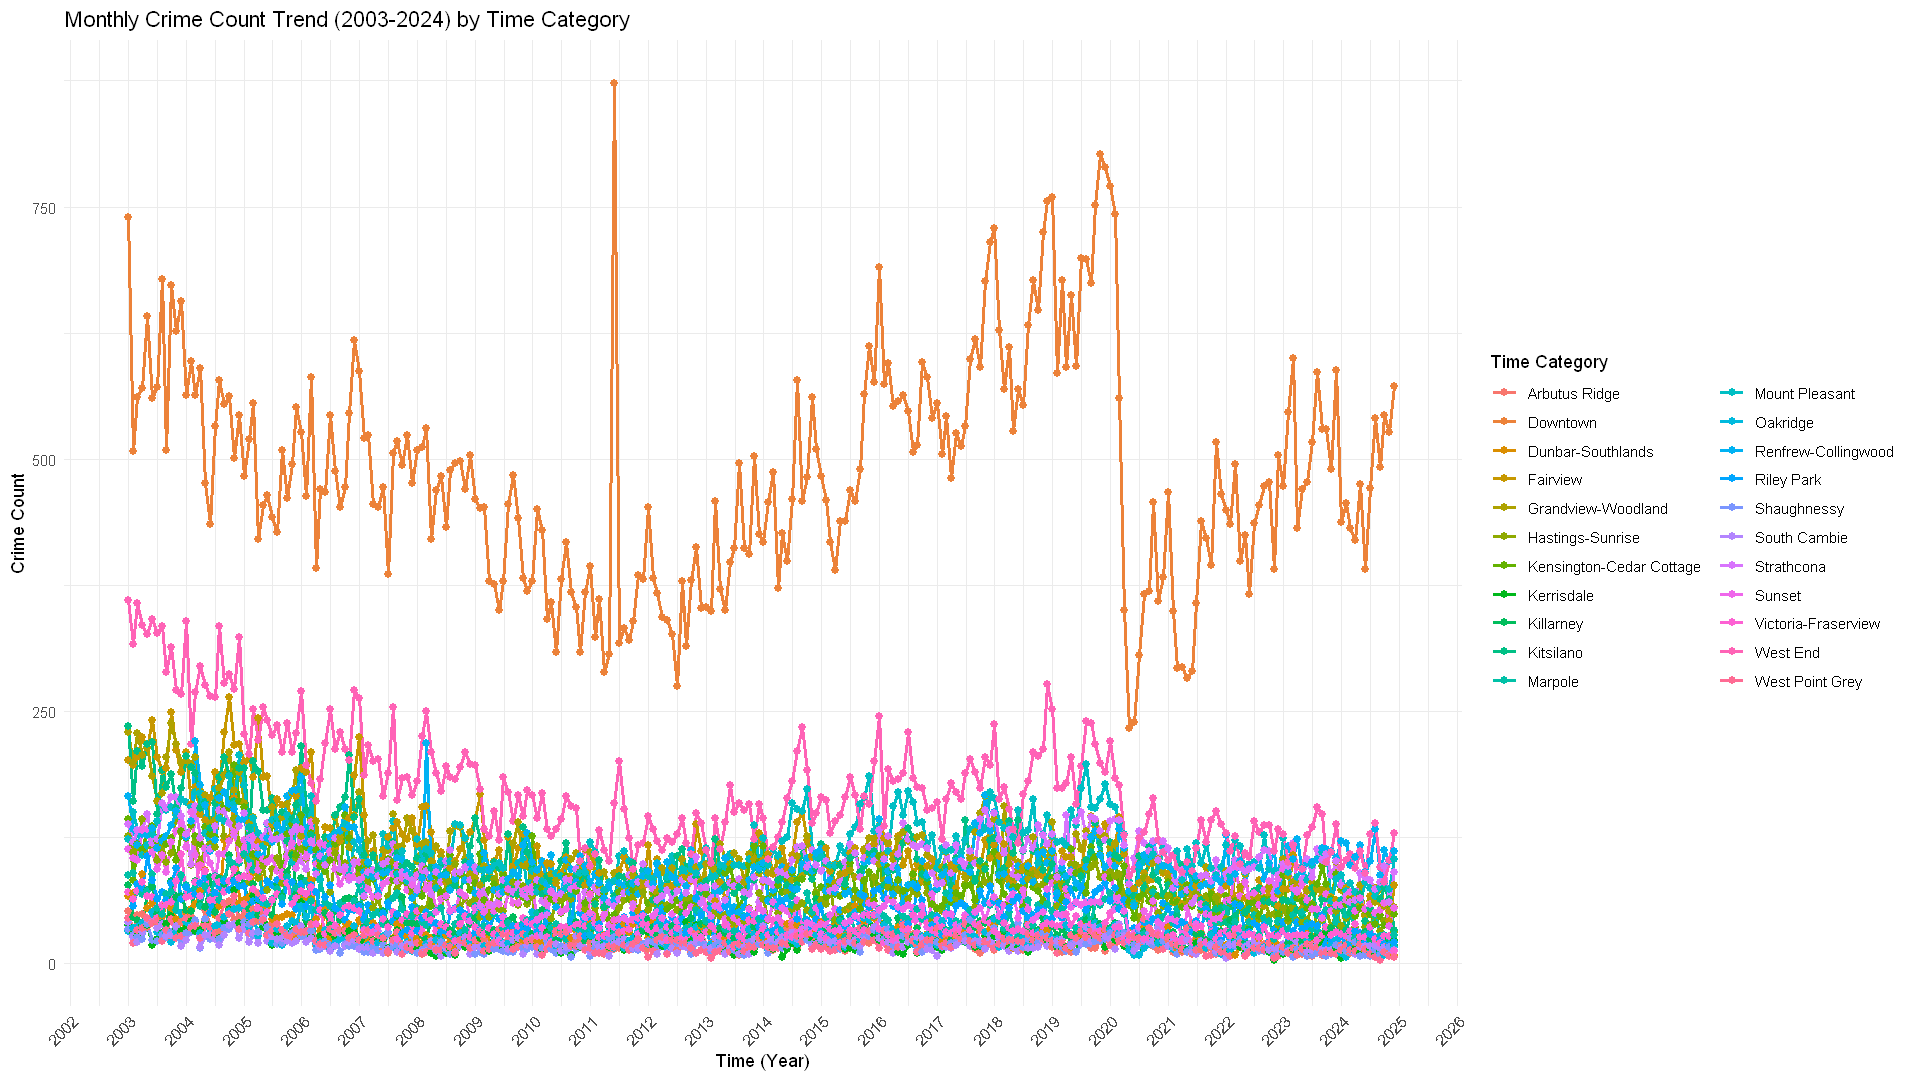

In [12]:

ggplot(crime_trend_neighborhood, aes(x = date, y = crime_count, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [13]:
crime_trend_dt <- crime_all|>
    filter(geo_local_area == "Downtown")|>
    group_by(time_category, year, month, geo_local_area)|>
    summarise(crime_count = n(), .groups = "drop")|>
    mutate(log_crime_count = log(crime_count))|>
    ungroup()|>
    filter(time_category == "night")|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 267
Columns: 7
$ time_category   <chr> "night", "night", "night", "night", "night", "night", …
$ year            <dbl> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ geo_local_area  <chr> "Downtown", "Downtown", "Downtown", "Downtown", "Downt…
$ crime_count     <int> 740, 508, 561, 570, 641, 560, 571, 678, 509, 672, 627,…
$ log_crime_count <dbl> 6.606650, 6.230481, 6.329721, 6.345636, 6.463029, 6.32…
$ date            <date> 2003-01-01, 2003-02-01, 2003-03-01, 2003-04-01, 2003-…


Warning message:
"Removed 123 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 123 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 11 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`)."


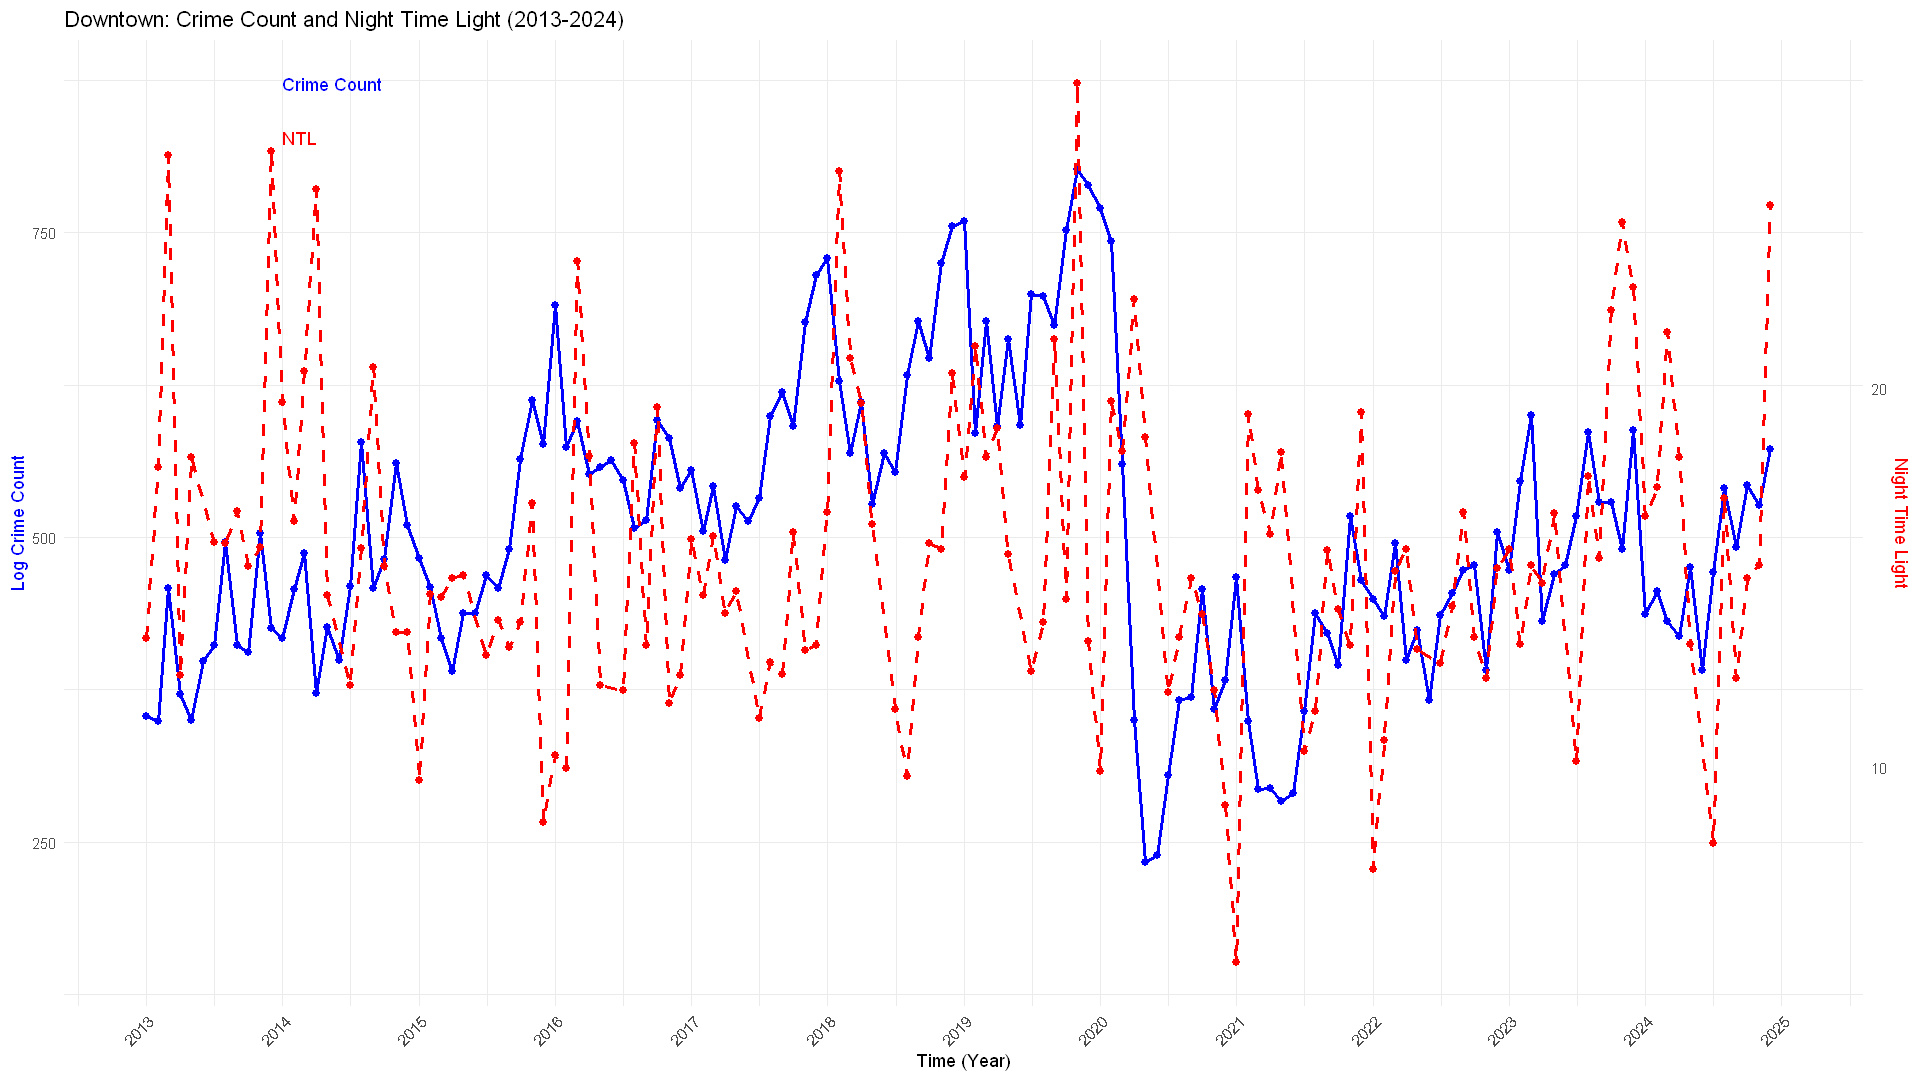

Overall correlation between crime count and NTL: 0.113

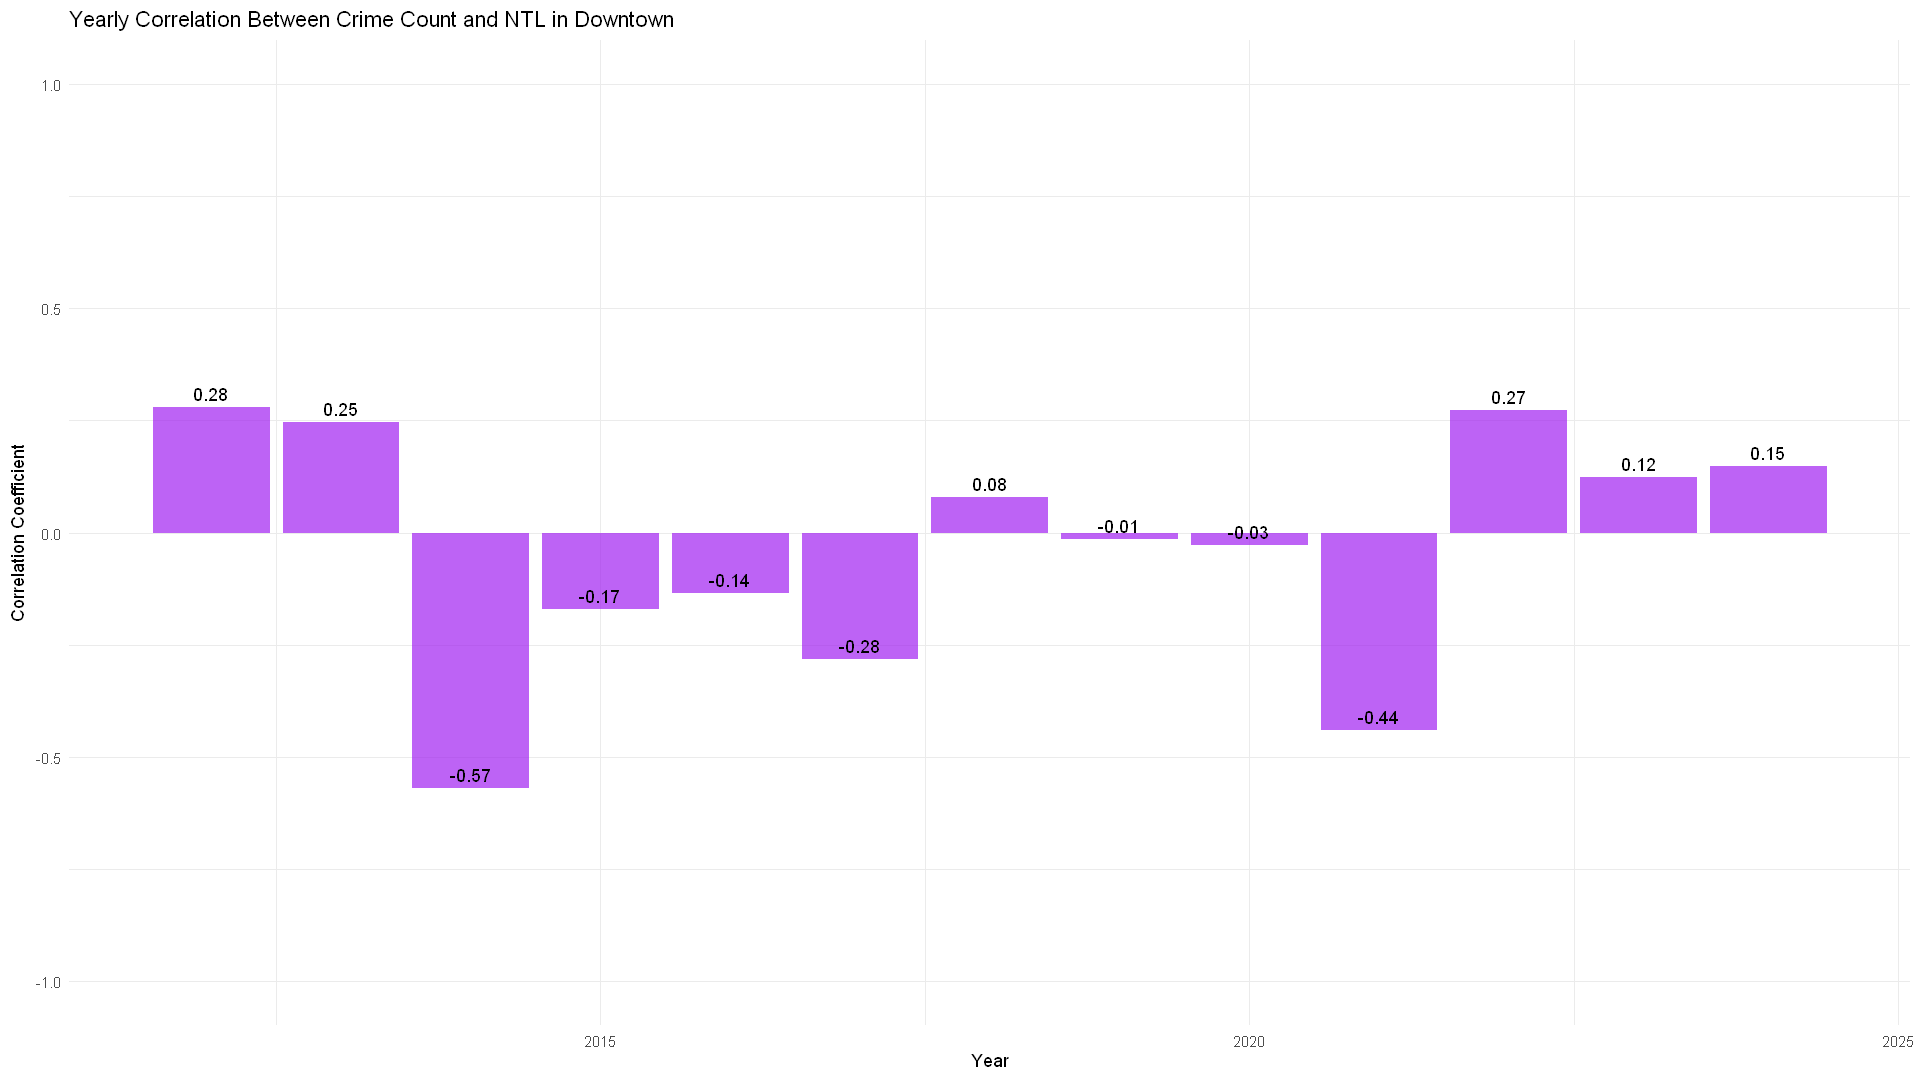

In [14]:

  # Prepare Downtown NTL data to match with crime_trend_dt
  ntl_monthly_dt <- ntl_12_24_monthly %>%
    filter(name == "Downtown") %>%
    filter(date >= min(crime_trend_dt$date) & date <= max(crime_trend_dt$date))

  # Set up the plot with dual y-axis
  p <- ggplot() +
    # Primary y-axis: crime count
    geom_line(data = crime_trend_dt, aes(x = date, y = crime_count), 
              color = "blue", size = 1) +
    geom_point(data = crime_trend_dt, aes(x = date, y = crime_count), 
               color = "blue", size = 2) +
    # Secondary y-axis: NTL data
    geom_line(data = ntl_monthly_dt, aes(x = date, y = ntl_mean/max(ntl_mean)*max(crime_trend_dt$crime_count)), 
              color = "red", size = 1, linetype = "dashed") +
    geom_point(data = ntl_monthly_dt, aes(x = date, y = ntl_mean/max(ntl_mean)*max(crime_trend_dt$crime_count)), 
               color = "red", size = 2) +
    scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
                 limits = as.Date(c("2013-01-01", "2024-12-31"))) +
    scale_y_continuous(
      name = "Log Crime Count",
      sec.axis = sec_axis(~.*max(ntl_monthly_dt$ntl_mean)/max(crime_trend_dt$crime_count), 
                          name = "Night Time Light")
    ) +
    labs(title = "Downtown: Crime Count and Night Time Light (2013-2024)",
         x = "Time (Year)") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          axis.title.y.left = element_text(color = "blue"),
          axis.title.y.right = element_text(color = "red")) +
    annotate("text", x = as.Date("2014-01-01"), y = max(crime_trend_dt$crime_count), 
             label = "Crime Count", color = "blue", hjust = 0) +
    annotate("text", x = as.Date("2014-01-01"), y = max(crime_trend_dt$crime_count)*0.95, 
             label = "NTL", color = "red", hjust = 0)
  p
  # Calculate correlation by year
  correlation_data <- merge(crime_trend_dt, ntl_monthly_dt[, c("date", "ntl_mean")], by = "date")

  yearly_correlation <- correlation_data %>%
    mutate(year = year(date)) %>%
    group_by(year) %>%
    summarize(correlation = cor(crime_count, ntl_mean, use = "complete.obs"),
              n = n()) %>%
    filter(n >= 3)  # Ensure at least 3 points per year for correlation

  # Create correlation plot
  corr_plot <- ggplot(yearly_correlation, aes(x = year, y = correlation)) +
    geom_bar(stat = "identity", fill = "purple", alpha = 0.7) +
    geom_text(aes(label = round(correlation, 2)), vjust = -0.5) +
    labs(title = "Yearly Correlation Between Crime Count and NTL in Downtown",
         x = "Year", y = "Correlation Coefficient") +
    theme_minimal() +
    ylim(-1, 1)

  # Display the correlation plot
  print(corr_plot)

  # Calculate overall correlation
  overall_corr <- cor(correlation_data$crime_count, correlation_data$ntl_mean, use = "complete.obs")
  cat("Overall correlation between crime count and NTL:", round(overall_corr, 3))
  

In [15]:
head(crime_all)

type,date,year,month,geo_local_area,time_category
<chr>,<date>,<dbl>,<dbl>,<chr>,<chr>
Break and Enter Commercial,2012-12-14,2012,12,South Cambie,day
Break and Enter Commercial,2019-03-07,2019,3,Fairview,night
Break and Enter Commercial,2019-08-27,2019,8,West End,night
Break and Enter Commercial,2021-04-26,2021,4,West End,night
Break and Enter Commercial,2014-08-08,2014,8,West End,night
Break and Enter Commercial,2020-07-28,2020,7,West End,night


Rows: 266
Columns: 7
$ time_category   <chr> "night", "night", "night", "night", "night", "night", …
$ year            <dbl> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ geo_local_area  <chr> "Downtown", "Downtown", "Downtown", "Downtown", "Downt…
$ crime_count     <int> 13, 17, 21, 24, 16, 16, 23, 17, 27, 22, 17, 21, 23, 15…
$ log_crime_count <dbl> 2.564949, 2.833213, 3.044522, 3.178054, 2.772589, 2.77…
$ date            <date> 2003-01-01, 2003-02-01, 2003-03-01, 2003-04-01, 2003-…


Warning message:
"Removed 122 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 122 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 11 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`)."


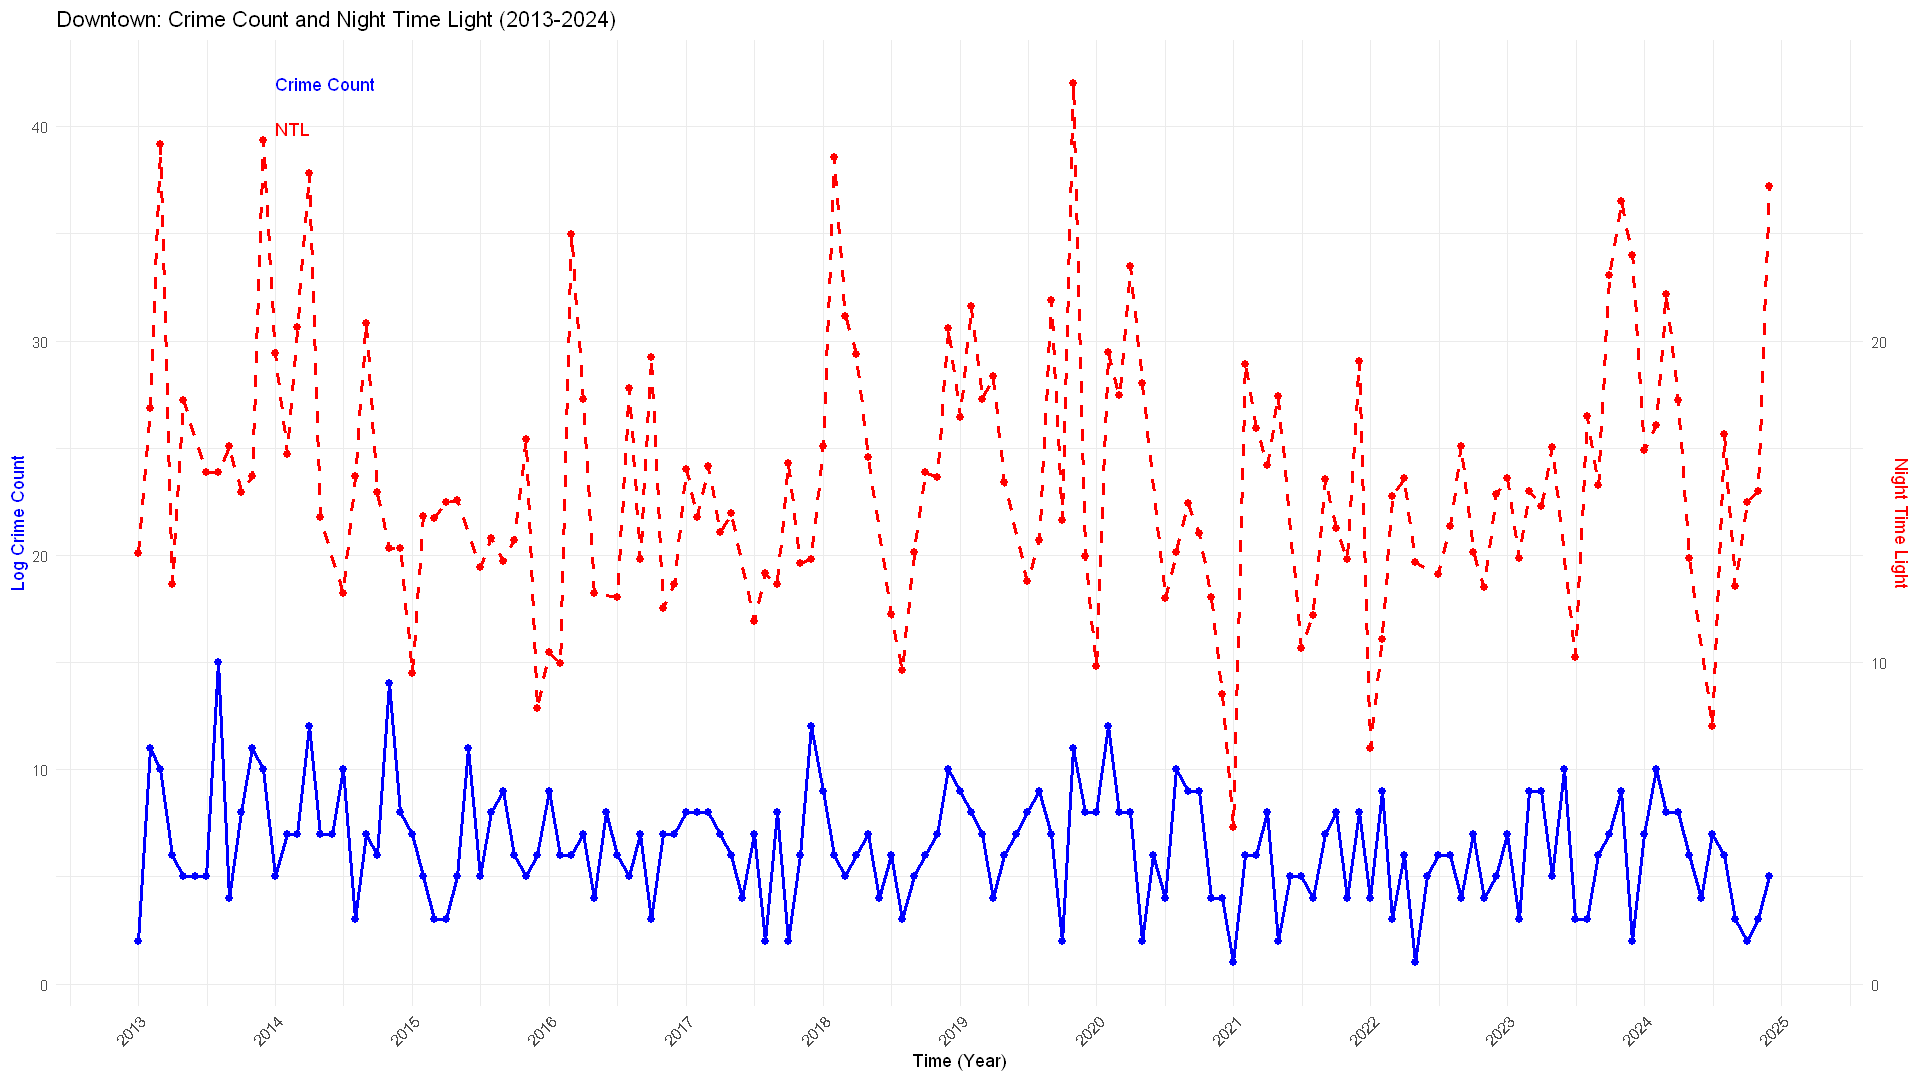

Overall correlation between crime count and NTL: 0.218

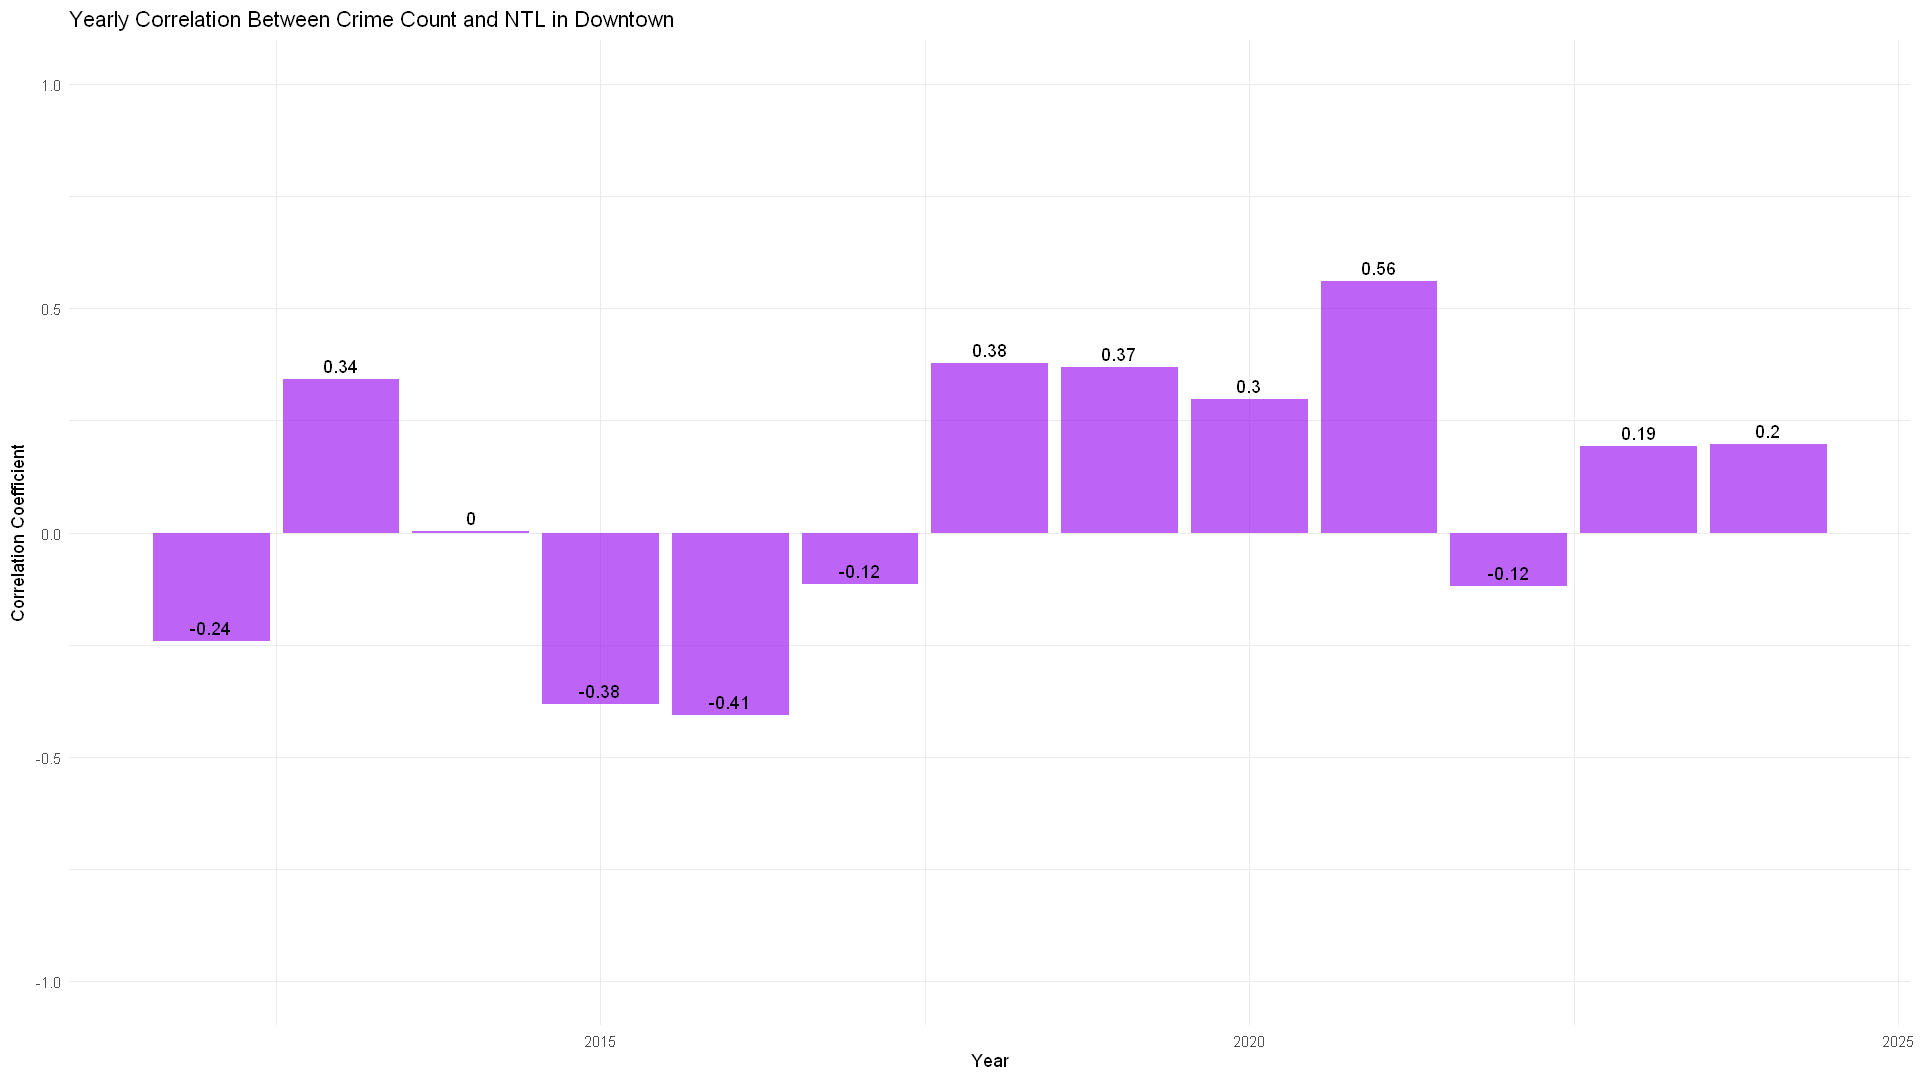

In [16]:
crime_type_only <- crime_all|>
    filter(type == "Break and Enter Residential/Other")


crime_trend_dt <- crime_type_only|>
    filter(geo_local_area == "Downtown")|>
    group_by(time_category, year, month, geo_local_area)|>
    summarise(crime_count = n(), .groups = "drop")|>
    mutate(log_crime_count = log(crime_count))|>
    ungroup()|>
    filter(time_category == "night")|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()


  # Prepare Downtown NTL data to match with crime_trend_dt
  ntl_monthly_dt <- ntl_12_24_monthly %>%
    filter(name == "Downtown") %>%
    filter(date >= min(crime_trend_dt$date) & date <= max(crime_trend_dt$date))

  # Set up the plot with dual y-axis
  p <- ggplot() +
    # Primary y-axis: crime count
    geom_line(data = crime_trend_dt, aes(x = date, y = crime_count), 
              color = "blue", size = 1) +
    geom_point(data = crime_trend_dt, aes(x = date, y = crime_count), 
               color = "blue", size = 2) +
    # Secondary y-axis: NTL data
    geom_line(data = ntl_monthly_dt, aes(x = date, y = ntl_mean/max(ntl_mean)*max(crime_trend_dt$crime_count)), 
              color = "red", size = 1, linetype = "dashed") +
    geom_point(data = ntl_monthly_dt, aes(x = date, y = ntl_mean/max(ntl_mean)*max(crime_trend_dt$crime_count)), 
               color = "red", size = 2) +
    scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
                 limits = as.Date(c("2013-01-01", "2024-12-31"))) +
    scale_y_continuous(
      name = "Log Crime Count",
      sec.axis = sec_axis(~.*max(ntl_monthly_dt$ntl_mean)/max(crime_trend_dt$crime_count), 
                          name = "Night Time Light")
    ) +
    labs(title = "Downtown: Crime Count and Night Time Light (2013-2024)",
         x = "Time (Year)") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          axis.title.y.left = element_text(color = "blue"),
          axis.title.y.right = element_text(color = "red")) +
    annotate("text", x = as.Date("2014-01-01"), y = max(crime_trend_dt$crime_count), 
             label = "Crime Count", color = "blue", hjust = 0) +
    annotate("text", x = as.Date("2014-01-01"), y = max(crime_trend_dt$crime_count)*0.95, 
             label = "NTL", color = "red", hjust = 0)
  p
  # Calculate correlation by year
  correlation_data <- merge(crime_trend_dt, ntl_monthly_dt[, c("date", "ntl_mean")], by = "date")

  yearly_correlation <- correlation_data %>%
    mutate(year = year(date)) %>%
    group_by(year) %>%
    summarize(correlation = cor(crime_count, ntl_mean, use = "complete.obs"),
              n = n()) %>%
    filter(n >= 3)  # Ensure at least 3 points per year for correlation

  # Create correlation plot
  corr_plot <- ggplot(yearly_correlation, aes(x = year, y = correlation)) +
    geom_bar(stat = "identity", fill = "purple", alpha = 0.7) +
    geom_text(aes(label = round(correlation, 2)), vjust = -0.5) +
    labs(title = "Yearly Correlation Between Crime Count and NTL in Downtown",
         x = "Year", y = "Correlation Coefficient") +
    theme_minimal() +
    ylim(-1, 1)

  # Display the correlation plot
  print(corr_plot)

  # Calculate overall correlation
  overall_corr <- cor(correlation_data$crime_count, correlation_data$ntl_mean, use = "complete.obs")
  cat("Overall correlation between crime count and NTL:", round(overall_corr, 3))
  

Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 12 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 11 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 11 rows containing missing values or values outside the scale range
(`geom_point()`)."


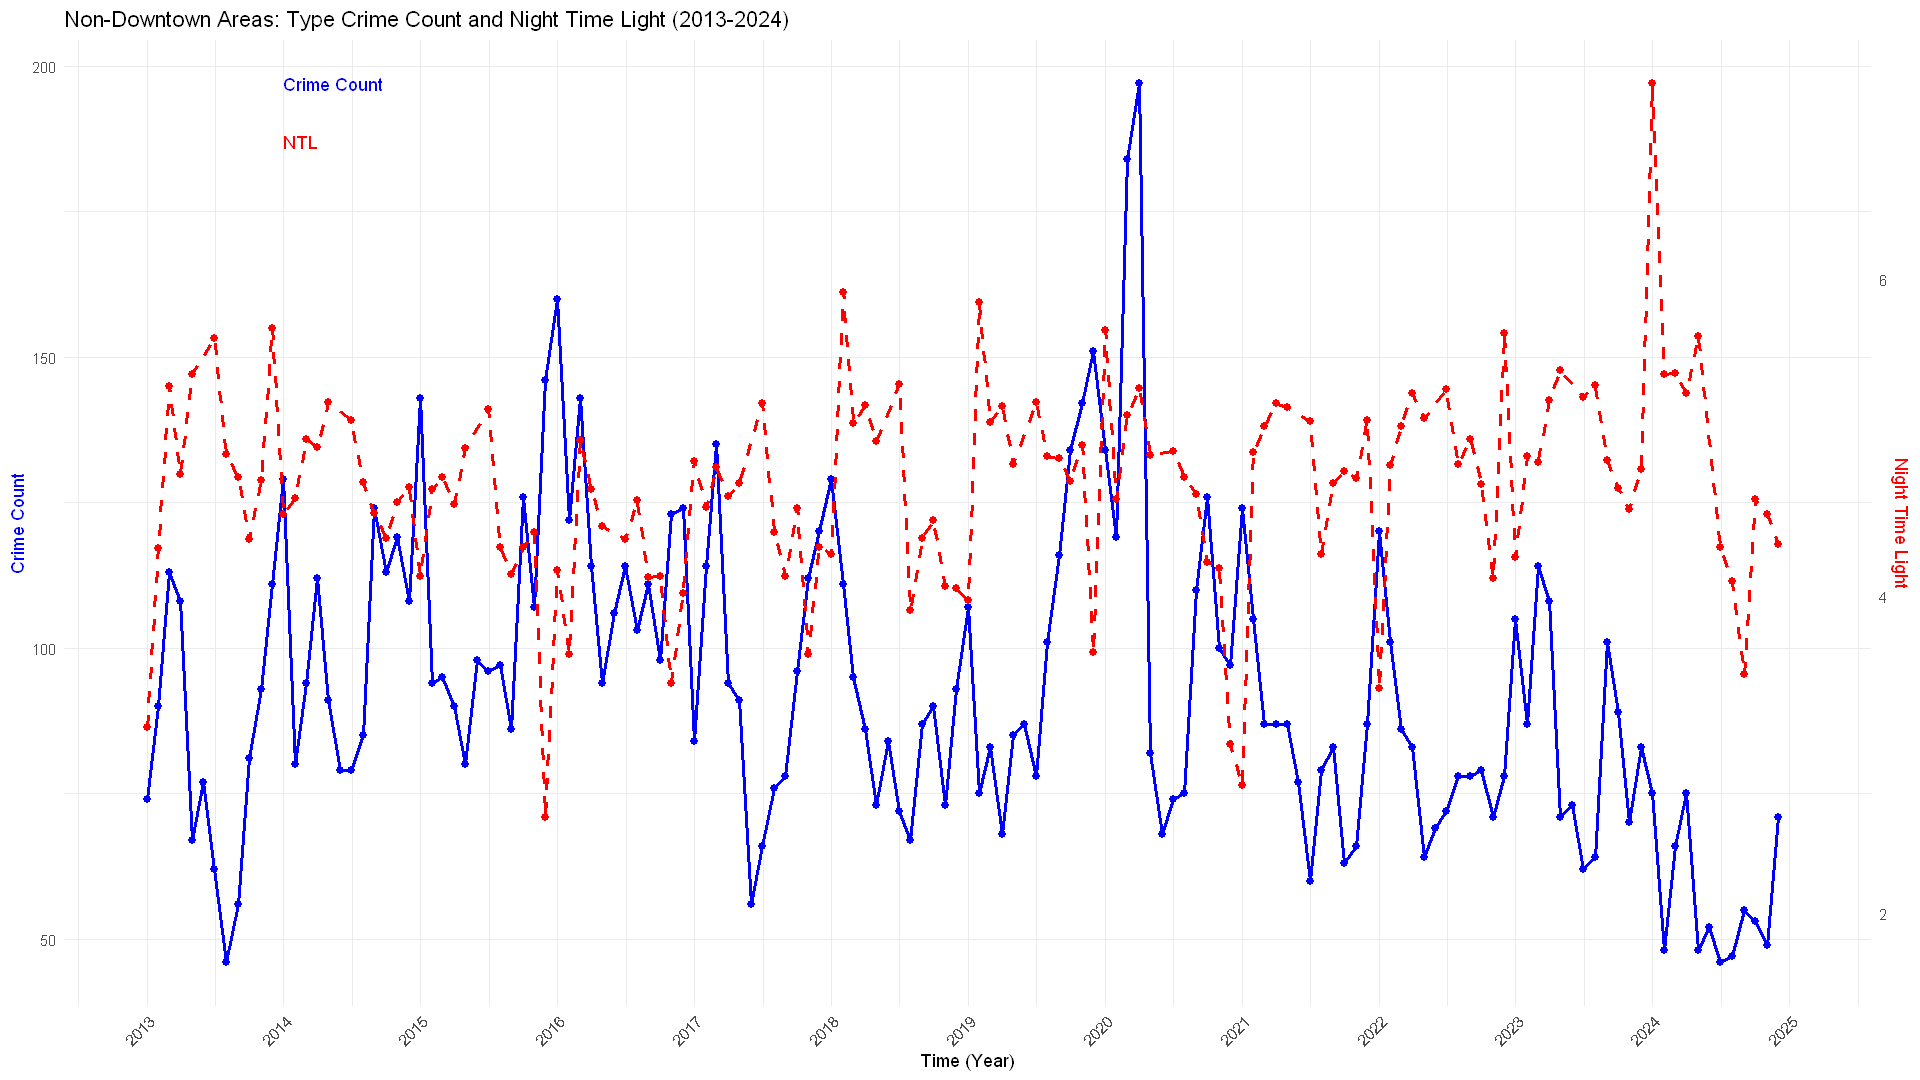

Overall correlation between mischief crime count and NTL in non-Downtown areas: -0.232

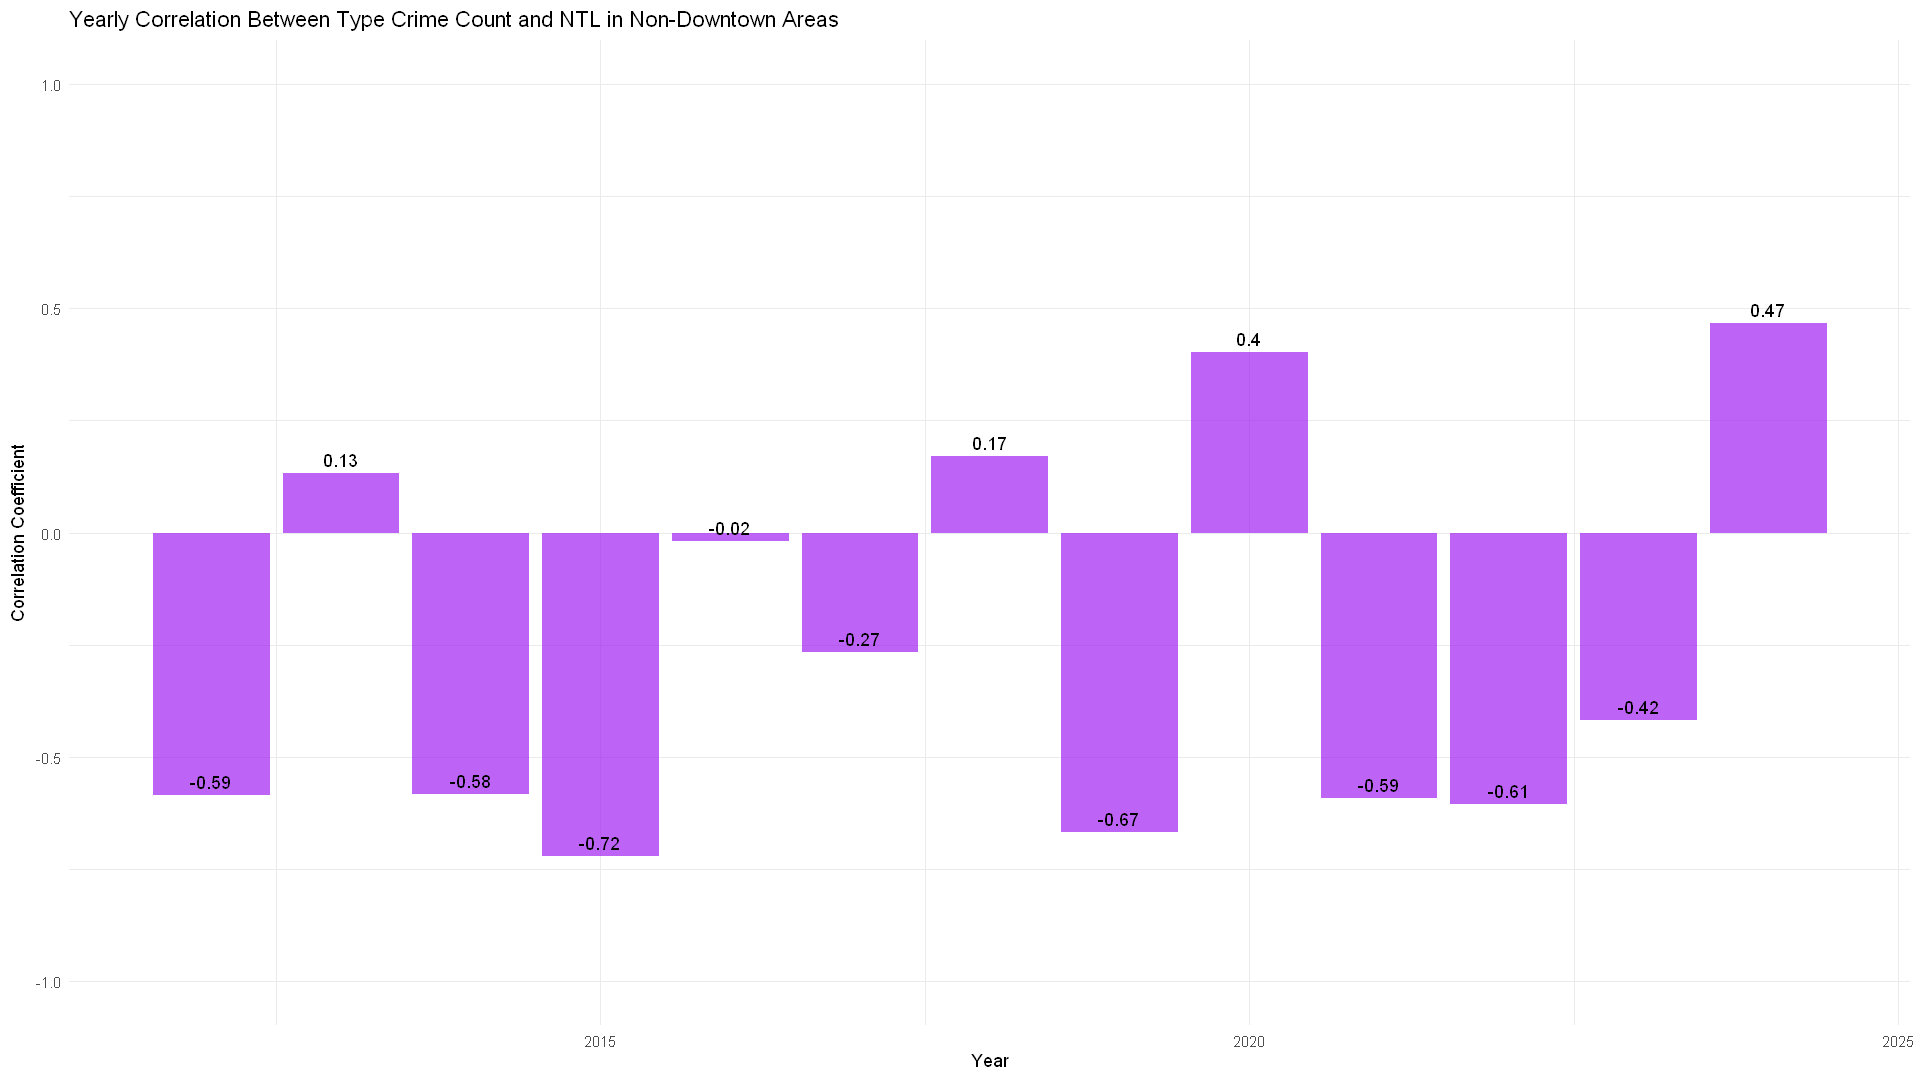

In [17]:
# Filter for crime type
crime_type_only <- crime_all |>
  filter(type == "Break and Enter Commercial")

# Create data for non-Downtown areas
crime_trend_non_dt <- crime_type_only |>
  filter(geo_local_area != "Downtown") |>
  group_by(time_category, year, month, geo_local_area) |>
  summarise(crime_count = n(), .groups = "drop") |>
  mutate(log_crime_count = log(crime_count)) |>
  ungroup() |>
  filter(time_category == "night") |>
  mutate(date = as.Date(paste(year, month, "01", sep = "-")))

# Aggregate non-Downtown data
crime_trend_non_dt_agg <- crime_trend_non_dt |>
  group_by(date, time_category) |>
  summarise(crime_count = sum(crime_count), .groups = "drop") |>
  filter(date >= min(ntl_12_24_monthly$date) & date <= max(ntl_12_24_monthly$date))

# Prepare non-Downtown NTL data by averaging all non-Downtown areas
ntl_monthly_non_dt <- ntl_12_24_monthly |>
  filter(name != "Downtown") |>
  group_by(date) |>
  summarise(ntl_mean = mean(ntl_mean, na.rm = TRUE), .groups = "drop") |>
  filter(date >= min(crime_trend_non_dt_agg$date) & date <= max(crime_trend_non_dt_agg$date))

# Set up the plot with dual y-axis
p <- ggplot() +
  # Primary y-axis: crime count
  geom_line(data = crime_trend_non_dt_agg, aes(x = date, y = crime_count), 
      color = "blue", size = 1) +
  geom_point(data = crime_trend_non_dt_agg, aes(x = date, y = crime_count), 
       color = "blue", size = 2) +
  # Secondary y-axis: NTL data
  geom_line(data = ntl_monthly_non_dt, aes(x = date, y = ntl_mean/max(ntl_mean)*max(crime_trend_non_dt_agg$crime_count)), 
      color = "red", size = 1, linetype = "dashed") +
  geom_point(data = ntl_monthly_non_dt, aes(x = date, y = ntl_mean/max(ntl_mean)*max(crime_trend_non_dt_agg$crime_count)), 
       color = "red", size = 2) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", 
         limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  scale_y_continuous(
  name = "Crime Count",
  sec.axis = sec_axis(~.*max(ntl_monthly_non_dt$ntl_mean)/max(crime_trend_non_dt_agg$crime_count), 
            name = "Night Time Light")
  ) +
  labs(title = "Non-Downtown Areas: Type Crime Count and Night Time Light (2013-2024)",
     x = "Time (Year)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    axis.title.y.left = element_text(color = "blue"),
    axis.title.y.right = element_text(color = "red")) +
  annotate("text", x = as.Date("2014-01-01"), y = max(crime_trend_non_dt_agg$crime_count), 
       label = "Crime Count", color = "blue", hjust = 0) +
  annotate("text", x = as.Date("2014-01-01"), y = max(crime_trend_non_dt_agg$crime_count)*0.95, 
       label = "NTL", color = "red", hjust = 0)
p

# Calculate correlation by year
correlation_data <- merge(crime_trend_non_dt_agg, ntl_monthly_non_dt[, c("date", "ntl_mean")], by = "date")

yearly_correlation <- correlation_data %>%
  mutate(year = year(date)) %>%
  group_by(year) %>%
  summarize(correlation = cor(crime_count, ntl_mean, use = "complete.obs"),
      n = n()) %>%
  filter(n >= 3)  # Ensure at least 3 points per year for correlation

# Create correlation plot
corr_plot <- ggplot(yearly_correlation, aes(x = year, y = correlation)) +
  geom_bar(stat = "identity", fill = "purple", alpha = 0.7) +
  geom_text(aes(label = round(correlation, 2)), vjust = -0.5) +
  labs(title = "Yearly Correlation Between Type Crime Count and NTL in Non-Downtown Areas",
     x = "Year", y = "Correlation Coefficient") +
  theme_minimal() +
  ylim(-1, 1)

# Display the correlation plot
print(corr_plot)

# Calculate overall correlation
overall_corr <- cor(correlation_data$crime_count, correlation_data$ntl_mean, use = "complete.obs")
cat("Overall correlation between mischief crime count and NTL in non-Downtown areas:", round(overall_corr, 3))


Warning message:
"tz(): Don't know how to compute timezone for object of class pseries/factor; returning "UTC"."


Oneway (individual) effect Within Model

Call:
plm(formula = log_crime ~ log_ntl * is_downtown + month_factor, 
    data = panel_data_plm, effect = "individual", model = "within")

Balanced Panel: n = 22, T = 143, N = 3146

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-1.728381 -0.208183  0.015654  0.225557  1.063207 

Coefficients:
                     Estimate Std. Error t-value  Pr(>|t|)    
log_ntl             -0.119763   0.039316 -3.0461  0.002337 ** 
month_factor2       -0.113958   0.028395 -4.0133 6.128e-05 ***
month_factor3       -0.063059   0.028675 -2.1991  0.027942 *  
month_factor4       -0.093873   0.028588 -3.2836  0.001036 ** 
month_factor5       -0.137185   0.028599 -4.7968 1.688e-06 ***
month_factor7       -0.065548   0.028643 -2.2884  0.022178 *  
month_factor8       -0.032984   0.028053 -1.1758  0.239765    
month_factor9       -0.071161   0.027988 -2.5426  0.011052 *  
month_factor10      -0.016088   0.027977 -0.5751  0.565298    
month_factor11    

Twoways effects Within Model

Call:
plm(formula = log_crime ~ log_ntl * is_downtown, data = panel_data_plm, 
    effect = "twoways", model = "within")

Balanced Panel: n = 22, T = 143, N = 3146

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-1.2642485 -0.1590307  0.0046167  0.1658099  1.0251027 

Coefficients:
                    Estimate Std. Error t-value Pr(>|t|)
log_ntl             0.063271   0.048313  1.3096   0.1904
log_ntl:is_downtown 0.056785   0.094253  0.6025   0.5469

Total Sum of Squares:    222.12
Residual Sum of Squares: 221.88
R-Squared:      0.0010741
Adj. R-Squared: -0.054236
F-statistic: 1.60211 on 2 and 2980 DF, p-value: 0.20164

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


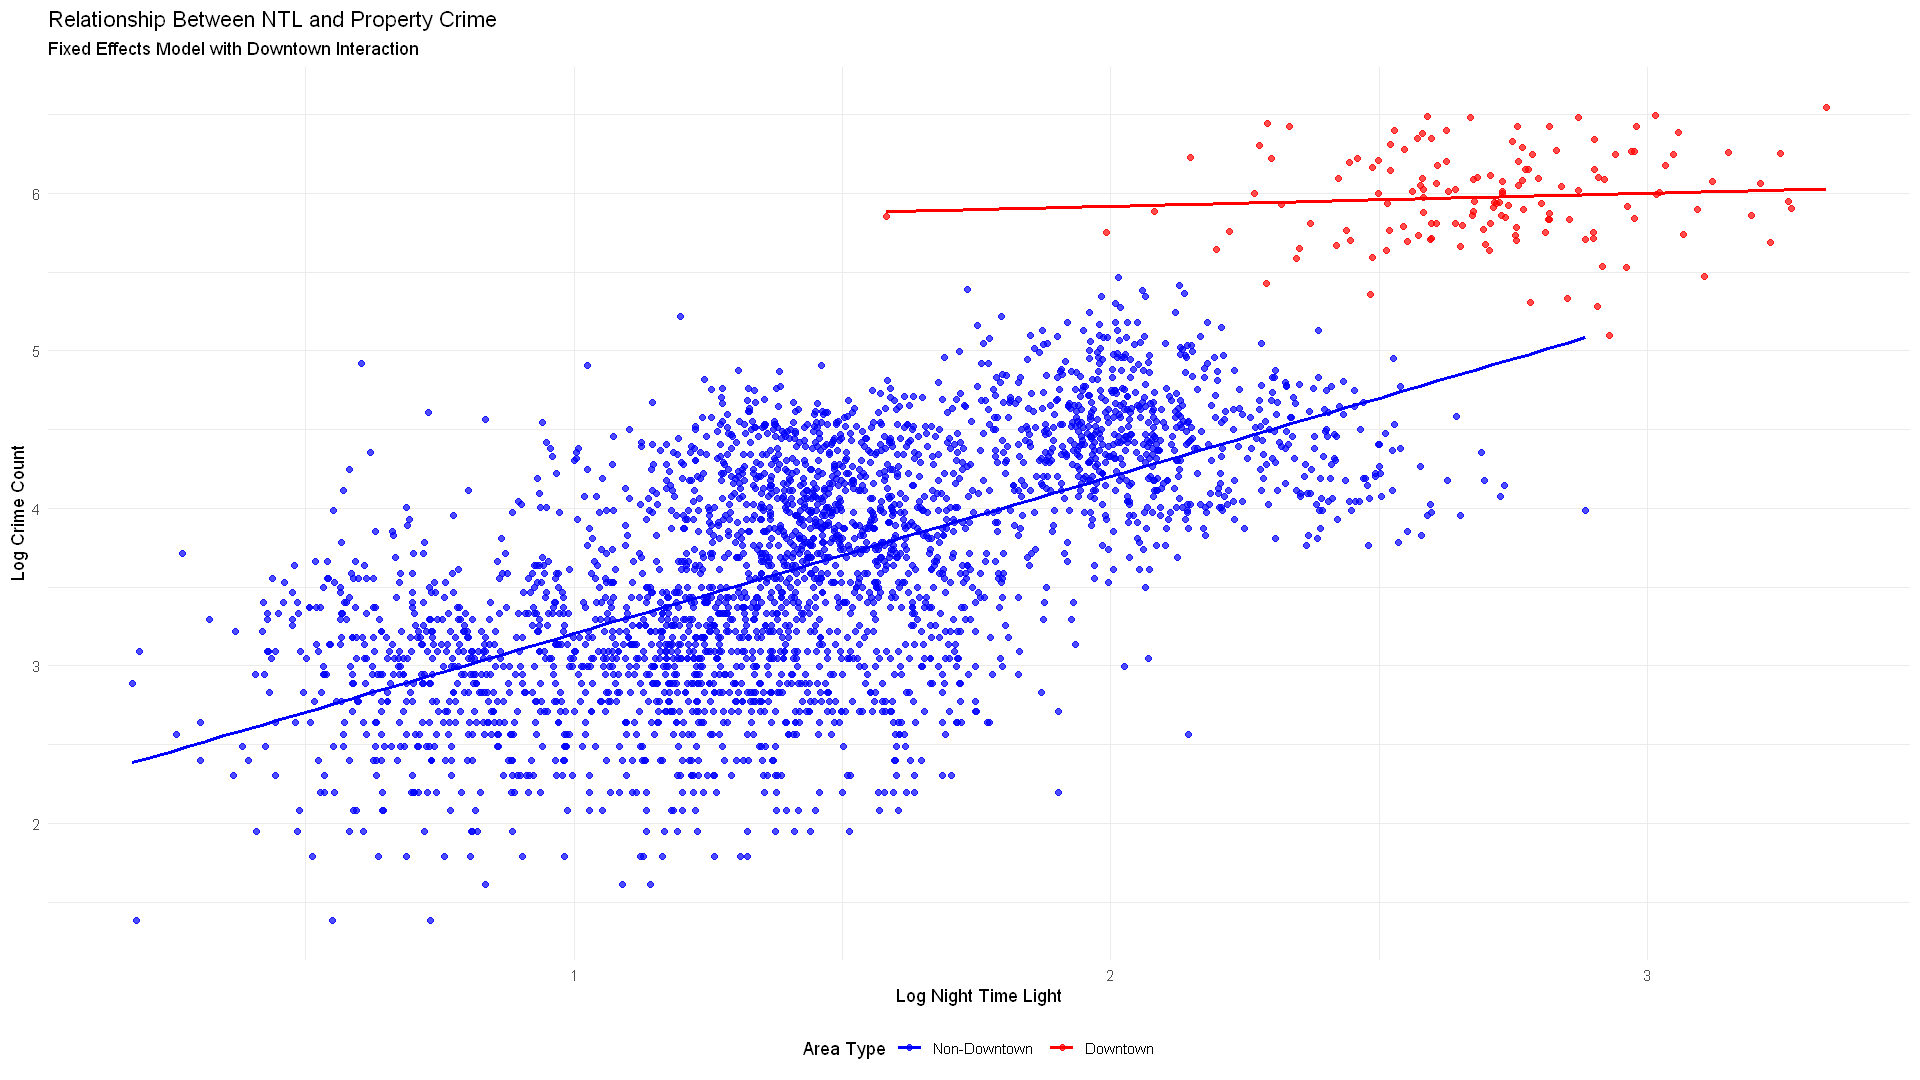

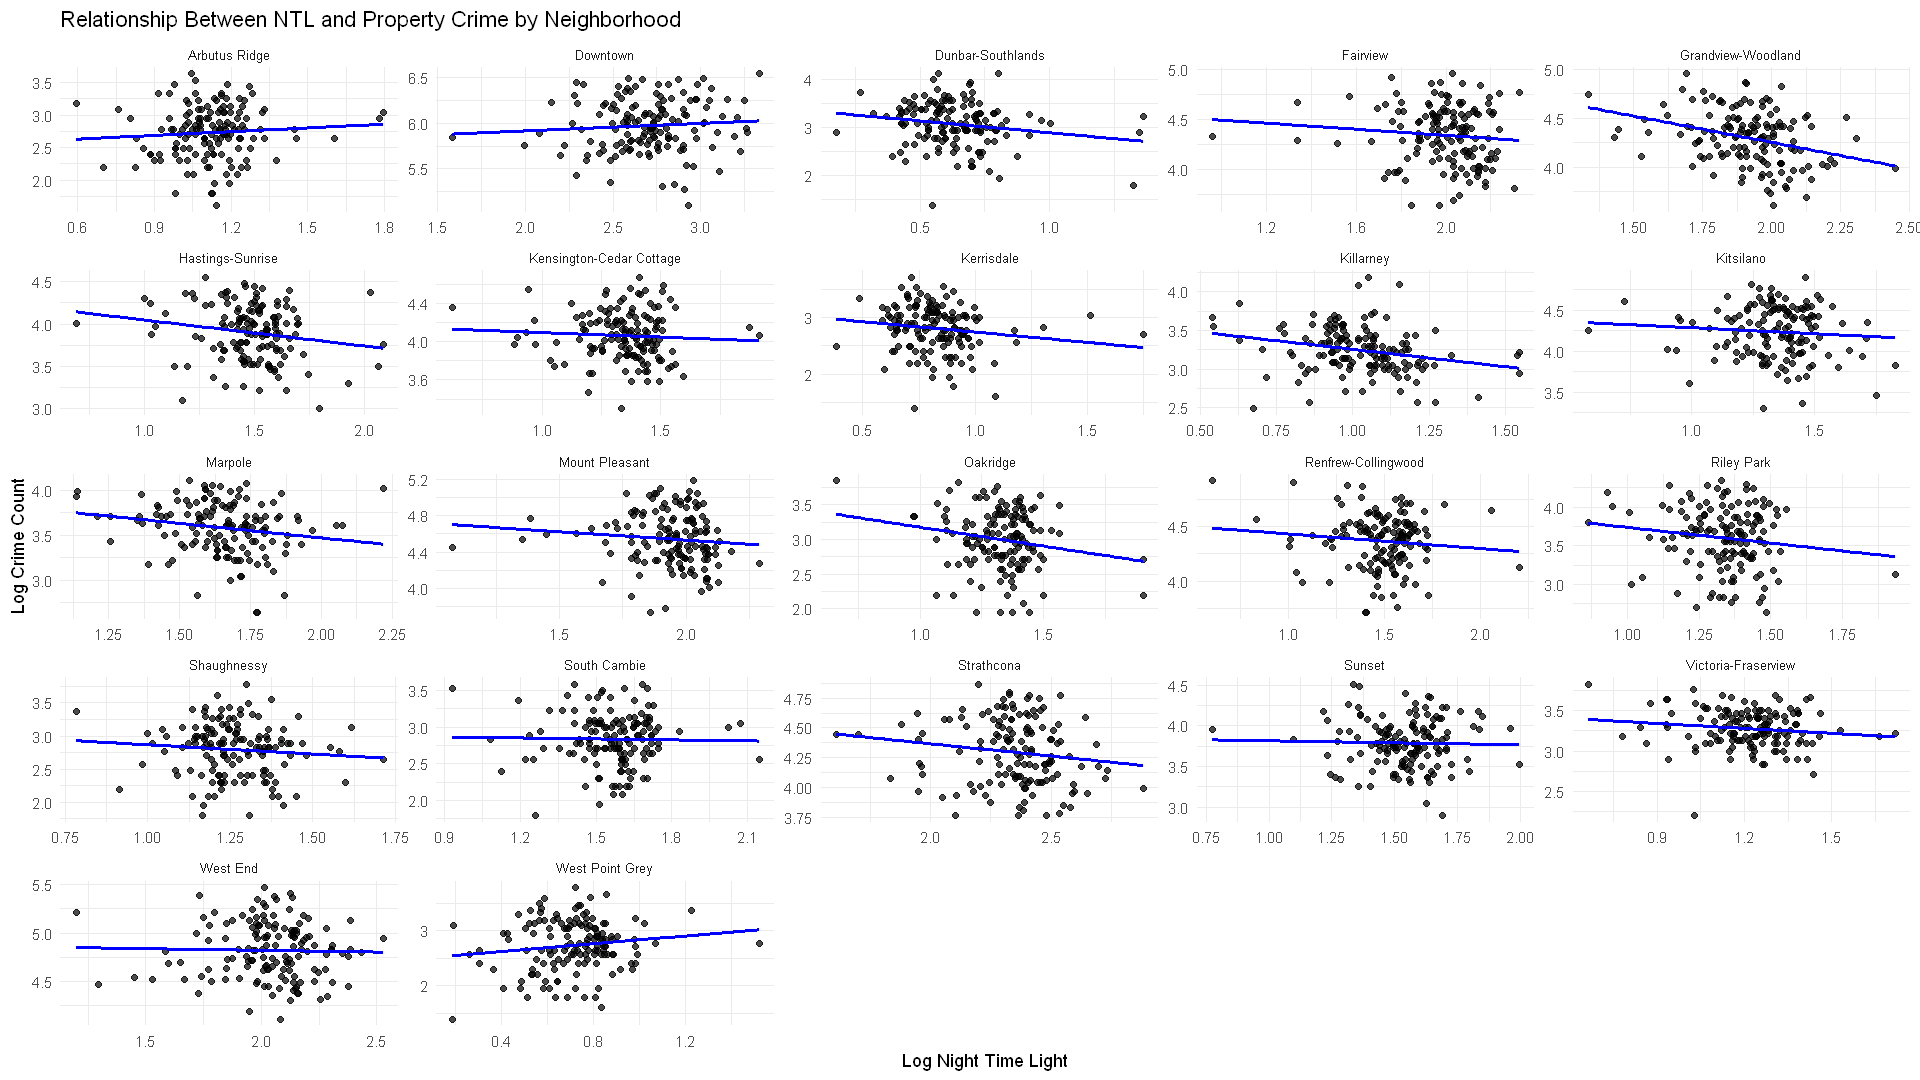

In [37]:
# Filter for multiple crime types
crime_type_only <- crime_all |>
    filter(type %in% c("Break and Enter Residential/Other", "Break and Enter Commercial",
                       "Theft from Vehicle","Theft of Vehicle","Theft of Bicycle",
                       "Other Theft"))

# Create data for all areas including Downtown
crime_trend_all <- crime_type_only |>
    filter(!is.na(geo_local_area)) |>
    group_by(time_category, year, month, geo_local_area) |>
    summarise(crime_count = n(), .groups = "drop") |>
    ungroup() |>
    filter(time_category == "night") |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))

# Create panel dataset by merging crime data with NTL data
panel_data <- crime_trend_all |>
    left_join(
        ntl_12_24_monthly |> 
            select(date, name, ntl_mean),
        by = c("date" = "date", "geo_local_area" = "name")
    ) |>
    filter(!is.na(ntl_mean)) |> # Remove rows with missing NTL data
    mutate(
        log_crime = log(crime_count + 1), # Adding 1 to handle zeros
        log_ntl = log(ntl_mean),
        is_downtown = ifelse(geo_local_area == "Downtown", 1, 0)
    )

# Load the plm package for panel data models
library(plm)

# Convert to panel data object
panel_data_plm <- pdata.frame(panel_data, index = c("geo_local_area", "date"))

# Run fixed effects model with interaction
fe_model_interaction <- plm(log_crime ~ log_ntl * is_downtown, 
                           data = panel_data_plm, 
                           model = "within", 
                           effect = "twoways")

# Alternative approach: explicitly include year and month fixed effects
# Create year and month factors
panel_data_plm$month_factor <- factor(month(panel_data_plm$date))

# Run model with explicit time controls
fe_model_time_controls <- plm(log_crime ~ log_ntl * is_downtown + month_factor, 
                             data = panel_data_plm, 
                             model = "within", 
                             effect = "individual")

# Compare models
summary(fe_model_time_controls)

# Display model summary
summary(fe_model_interaction)

# Create a visualization of actual vs fitted values
panel_data$fitted_interaction <- fitted(fe_model_interaction)

# Plot actual vs fitted with different slopes for Downtown vs non-Downtown
ggplot(panel_data, aes(x = log_ntl, y = log_crime, color = factor(is_downtown))) +
    geom_point(alpha = 0.7) +
    geom_smooth(method = "lm", se = FALSE) +
    scale_color_manual(values = c("blue", "red"), 
                      labels = c("Non-Downtown", "Downtown"),
                      name = "Area Type") +
    labs(title = "Relationship Between NTL and Property Crime",
         subtitle = "Fixed Effects Model with Downtown Interaction",
         x = "Log Night Time Light",
         y = "Log Crime Count") +
    theme_minimal() +
    theme(legend.position = "bottom")

# Create a facet plot to see the relationship in different neighborhoods
ggplot(panel_data, aes(x = log_ntl, y = log_crime)) +
    geom_point(alpha = 0.7) +
    geom_smooth(method = "lm", se = FALSE, color = "blue") +
    facet_wrap(~ geo_local_area, scales = "free") +
    labs(title = "Relationship Between NTL and Property Crime by Neighborhood",
         x = "Log Night Time Light",
         y = "Log Crime Count") +
    theme_minimal() +
    theme(strip.text = element_text(size = 8))